In [1]:
PP[u_, v_, Q_] := u^2((1-u)(u^2+A^2)-Q*u*v);
QQ[u_, v_, B_] := B(u-v)(u^2+A^2)v;

q = (1 - H)(A^2 + H^2)/H^2;
b = (H^2(1 - 2H) - A^2)/(A^2 + H^2);

2    2
       2                2          2    (-1 + H) (A  + H ) (H + u) (H + v)
(H + u)  ((1 - H - u) (A  + (H + u) ) + ----------------------------------)
                                                         2
                                                        H
    2    2               2          2
  (A  + H  (-1 + 2 H)) (A  + (H + u) ) (u - v) (H + v)
-(----------------------------------------------------)
                         2    2
                        A  + H
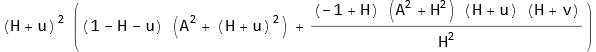
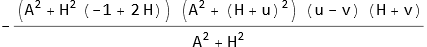

In [5]:
P1[u_, v_] = FullSimplify[PP[u + H, v + H, q]]
Q1[u_, v_] = FullSimplify[QQ[u + H, v + H, b]]

In [7]:
jac = FullSimplify[{{D[P1[u, v], u], D[P1[u, v], v]}, {D[Q1[u, v], u], D[Q1[u, v], v]}}] /. {u -> 0, v -> 0}

2       2          2                2    2
{{-(A  H) - H  (-H + 2 H ), (-1 + H) H (A  + H )}, 
 
           2    2                   2    2
>   {-(H (A  + H  (-1 + 2 H))), H (A  + H  (-1 + 2 H))}}

In [8]:
detY[B_] = B H^2(A^2 + H^2)(H^3 + A^2(2 − H));
detJ = FullSimplify[Det[jac]]
Simplify[detY[b] - detJ]
Simplify[Tr[jac]]

2     2              3    2    2
-(H  (-(A  (-2 + H)) + H ) (A  + H  (-1 + 2 H)))
0
0

4    4        2  2      2  3      2  4    5      6
{{-(H Sqrt[2 A  - A  H - 2 A  H  + 6 A  H  - 2 A  H  - H  + 2 H ]), 
 
               4    4        2  2      2  3      2  4    5      6
>    H Sqrt[2 A  - A  H - 2 A  H  + 6 A  H  - 2 A  H  - H  + 2 H ]}, 
 
          2    2      3           4    4        2  2      2  3      2  4    5      6
        -A  + H  - 2 H  - Sqrt[2 A  - A  H - 2 A  H  + 6 A  H  - 2 A  H  - H  + 2 H ]
>   {{-(-----------------------------------------------------------------------------), 
                                        2    2      3
                                       A  - H  + 2 H
 
>     1}, {-(
 
           2    2      3           4    4        2  2      2  3      2  4    5      6
         -A  + H  - 2 H  + Sqrt[2 A  - A  H - 2 A  H  + 6 A  H  - 2 A  H  - H  + 2 H ]
>        -----------------------------------------------------------------------------), 
                                         2    2      3
                                        A  - H  + 2 H
 
>     1}}}
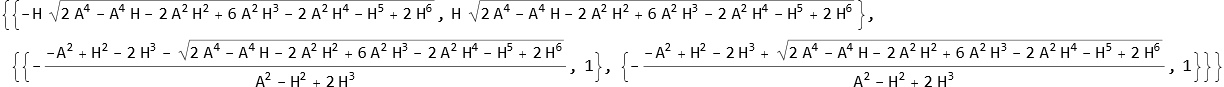

In [16]:
{vals, vecs} = Eigensystem[jac]

2             3
                     A  (-2 + H) - H
{1 + ------------------------------------------------, 1}
              2             3    2    2
     Sqrt[-((A  (-2 + H) - H ) (A  + H  (-1 + 2 H)))]
           2             3    2    2
H Sqrt[-((A  (-2 + H) - H ) (A  + H  (-1 + 2 H)))]
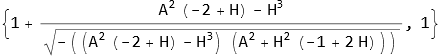

In [17]:
vectorp = FullSimplify[vecs[[2]]]
valorp = FullSimplify[vals[[2]]]

2             3
        A  (-2 + H) - H
{{Sqrt[------------------], 1}, {0, 1}}
        2    2
       A  + H  (-1 + 2 H)
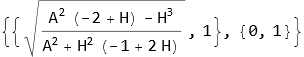

In [22]:
imv2 = {Sqrt[(A^2 (-2 + H) - H^3)^2/((A^2 + H^2 (-1 + 2H))(A^2(-2 + H)-H^3))], 0};
rev2 = {1, 1};
P = Transpose[{imv2, rev2}]

2       2          2                    2    2
{(-(A  H) - H  (-H + 2 H )) u + (-1 + H) H (A  + H ) v, 
 
          2    2                      2    2
>   -(H (A  + H  (-1 + 2 H)) u) + H (A  + H  (-1 + 2 H)) v}
  2        3                                   2   2          2
{A  H u + H  (-1 + 2 H) u + (1 - H - u) (H + u)  (A  + (H + u) ) - 
 
                                         2    2         3
                  2    2      (-1 + H) (A  + H ) (H + u)  (H + v)
>    (-1 + H) H (A  + H ) v + -----------------------------------, 
                                               2
                                              H
 
        2    2                                        2          2
      (A  + H  (-1 + 2 H)) (u - v) (H u (2 H + u) + (A  + (H + u) ) v)
>   -(----------------------------------------------------------------)}
                                   2    2
                                  A  + H
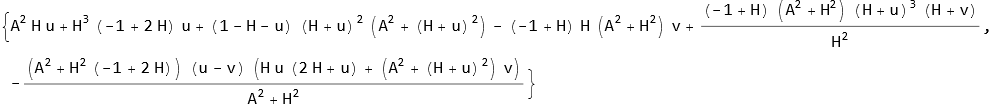

In [25]:
sistema = {P1[u, v], Q1[u, v]};
variables = {u, v};
lineal = jac . variables
noLineal = FullSimplify[sistema - lineal]

2               4                  2             3
        A  (-2 + H) H - H                  A  (-2 + H) - H      2    2
{{0, ------------------------}, {-(H Sqrt[------------------] (A  + H  (-1 + 2 H))), 0}}
            2             3                2    2
           A  (-2 + H) - H                A  + H  (-1 + 2 H)
     Sqrt[------------------]
           2    2
          A  + H  (-1 + 2 H)
                                    2             3
    2    2                         A  (-2 + H) - H
{((A  + H  (-1 + 2 H)) x (H (Sqrt[------------------] x + y) 
                                   2    2
                                  A  + H  (-1 + 2 H)
 
                         2             3
                        A  (-2 + H) - H
>          (2 H + Sqrt[------------------] x + y) + 
                        2    2
                       A  + H  (-1 + 2 H)
 
                              2             3
              2              A  (-2 + H) - H          2        2    2
>         y (A  + (H + Sqrt[------------------] x + y) ))) / (A  + H ) + 
                             2    2
                            A  + H  (-1 + 2 H)
 
                                               2             3
                     2    2        2          A  (-2 + H) - H
>    (-((-1 + H) H (A  + H ) y) + A  H (Sqrt[------------------] x + y) + 
                                              2    2
                                             A  + H  (-1 + 2 H)
 
                              2             3
         3                   A  (-2 + H) - H
>       H  (-1 + 2 H) (Sqrt[------------------] x + y) + 
                             2    2
                            A  + H  (-1 + 2 H)
 
                                               2             3
                   2    2                     A  (-2 + H) - H          3
        (-1 + H) (A  + H ) (H + y) (H + Sqrt[------------------] x + y)
                                              2    2
                                             A  + H  (-1 + 2 H)
>       ---------------------------------------------------------------- + 
                                        2
                                       H
 
                        2             3                      2             3
                       A  (-2 + H) - H                      A  (-2 + H) - H          2
>       (1 - H - Sqrt[------------------] x - y) (H + Sqrt[------------------] x + y)  
                       2    2                               2    2
                      A  + H  (-1 + 2 H)                   A  + H  (-1 + 2 H)
 
                           2             3                      2             3
           2              A  (-2 + H) - H          2           A  (-2 + H) - H
>        (A  + (H + Sqrt[------------------] x + y) )) / Sqrt[------------------], 
                          2    2                               2    2
                         A  + H  (-1 + 2 H)                   A  + H  (-1 + 2 H)
 
              2             3
             A  (-2 + H) - H      2    2
>   -((Sqrt[------------------] (A  + H  (-1 + 2 H)) x 
             2    2
            A  + H  (-1 + 2 H)
 
                    2             3                        2             3
                   A  (-2 + H) - H                        A  (-2 + H) - H
>        (H (Sqrt[------------------] x + y) (2 H + Sqrt[------------------] x + y) + 
                   2    2                                 2    2
                  A  + H  (-1 + 2 H)                     A  + H  (-1 + 2 H)
 
                               2             3
               2              A  (-2 + H) - H          2        2    2
>          y (A  + (H + Sqrt[------------------] x + y) ))) / (A  + H ))}
                              2    2
                             A  + H  (-1 + 2 H)
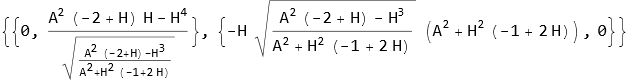
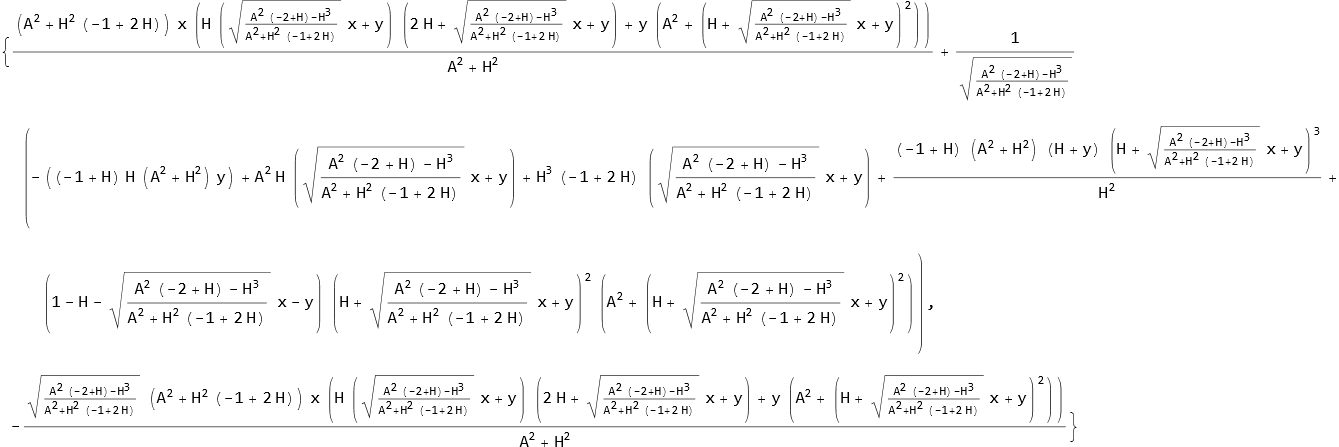

In [29]:
varsO = {u, v};
varsN = {x, y};
cambio = Thread[varsO -> P . varsN];
inv = Inverse[P];
matrizNormal = FullSimplify[inv . jac . P]
nonLinearNormal = FullSimplify[inv . (noLineal /. cambio)]

2             3
        A  (-2 + H) - H      2    2
H Sqrt[------------------] (A  + H  (-1 + 2 H)) - 
        2    2
       A  + H  (-1 + 2 H)
 
          2   2             3    2    2
>   Sqrt[H  (A  (-2 + H) - H ) (A  + H  (-1 + 2 H))]
                           2             3
     2    2      3        A  (-2 + H) - H
H (-A  + H  - 2 H ) Sqrt[------------------] + 
                          2    2
                         A  + H  (-1 + 2 H)
 
          2   2             3    2    2
>   Sqrt[H  (A  (-2 + H) - H ) (A  + H  (-1 + 2 H))]
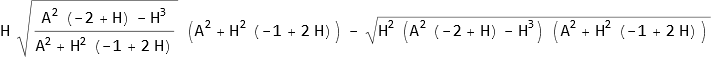
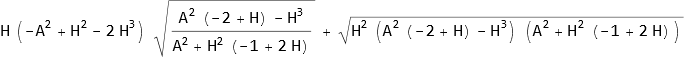

In [35]:
FullSimplify[matrizNormal[[1, 2]] - Sqrt[detY[b]]]
FullSimplify[matrizNormal[[2, 1]] + Sqrt[detY[b]]]

2      2        3   2        2      2        3   3
(-5 A  + 3 A  H - 4 H ) y    (-4 A  + 3 A  H - 6 H ) y
-------------------------- + -------------------------- + 
        2             3               2             3
       A  (-2 + H) - H               A  (-2 + H) - H
 Sqrt[------------------]    H Sqrt[------------------]
       2    2                        2    2
      A  + H  (-1 + 2 H)            A  + H  (-1 + 2 H)
 
            2      2  2    4
     3  -2 A  H + A  H  - H        4    4        2  2       2  3      2  4      5
>   x  (-------------------- + (2 A  - A  H - 6 A  H  + 22 A  H  - 9 A  H  - 3 H  + 
               2    2
              A  + H
 
             6         2    2      3
>         9 H ) / (H (A  - H  + 2 H )) + 
 
            2    2      3
        -2 A  + A  H - H        4      4        2  2    4  2       2  3       2  4
>      (----------------- + (2 A  - 3 A  H - 6 A  H  + A  H  + 42 A  H  - 20 A  H  - 
              2    2
             A  + H
 
                                                               2    2      3   2
                5       6      2   2    2      3        10 (2 A  - A  H + H ) y
>            3 H  + 19 H ) / (H  (A  - H  + 2 H ))) y + ------------------------) + 
                                                              2    2      3
                                                             A  - H  + 2 H
 
     2      6      6        4  2       4  3      2  4      4  4      2  5      2  6
>   x  ((4 A  - 2 A  H - 6 A  H  + 19 A  H  - 2 A  H  - 7 A  H  + 4 A  H  + 4 A  H  - 
 
                                           2    2      3
           7      8       2    2       -2 A  + A  H - H     2    2      3
>         H  + 3 H ) / ((A  + H ) Sqrt[-----------------] (A  - H  + 2 H )) + 
                                         2    2      3
                                        A  - H  + 2 H
 
             6       6        4  2      6  2       4  3      2  4       4  4
>      ((12 A  - 12 A  H - 8 A  H  + 3 A  H  + 52 A  H  - 4 A  H  - 24 A  H  + 
 
                2  5      2  6      7       8
>           30 A  H  + 5 A  H  - 2 H  + 16 H ) y) / 
 
                              2    2      3
             2    2       -2 A  + A  H - H     2    2      3
>       (H (A  + H ) Sqrt[-----------------] (A  - H  + 2 H )) + 
                            2    2      3
                           A  - H  + 2 H
 
            6      6        4  2      6  2       4  3      2  4       4  4       2  5
>      ((6 A  - 9 A  H - 4 A  H  + 3 A  H  + 53 A  H  - 2 A  H  - 27 A  H  + 45 A  H  + 
 
             2  6    7       8   2
>           A  H  - H  + 23 H ) y ) / 
 
                               2    2      3
          2   2    2       -2 A  + A  H - H     2    2      3
>       (H  (A  + H ) Sqrt[-----------------] (A  - H  + 2 H )) + 
                             2    2      3
                            A  - H  + 2 H
 
                      2    2      3   3
               10 (2 A  - A  H + H ) y
>      ----------------------------------------) + 
                2    2      3
            -2 A  + A  H - H     2    2      3
       Sqrt[-----------------] (A  - H  + 2 H )
              2    2      3
             A  - H  + 2 H
 
             4      4        2  2      2  3      5         2    2
>   x (((-6 A  + 3 A  H - 2 A  H  - 6 A  H  - 5 H ) y) / (A  + H ) - 
 
              4      4      2  2      2  3      5   2         2    2
>      (3 (3 A  - 2 A  H + A  H  + 5 A  H  + 5 H ) y ) / (H (A  + H )) + 
 
             4      4      2  2       2  3       5   3      2   2    2
>      ((-3 A  + 3 A  H - A  H  - 14 A  H  - 15 H ) y ) / (H  (A  + H )))
             2    2      3
         -2 A  + A  H - H       2      2  2    4
    Sqrt[-----------------] (2 A  H - A  H  + H )
           2    2      3
 3        A  - H  + 2 H
x  (--------------------------------------------- + 
                        2    2
                       A  + H
 
                                   2    2      3
       
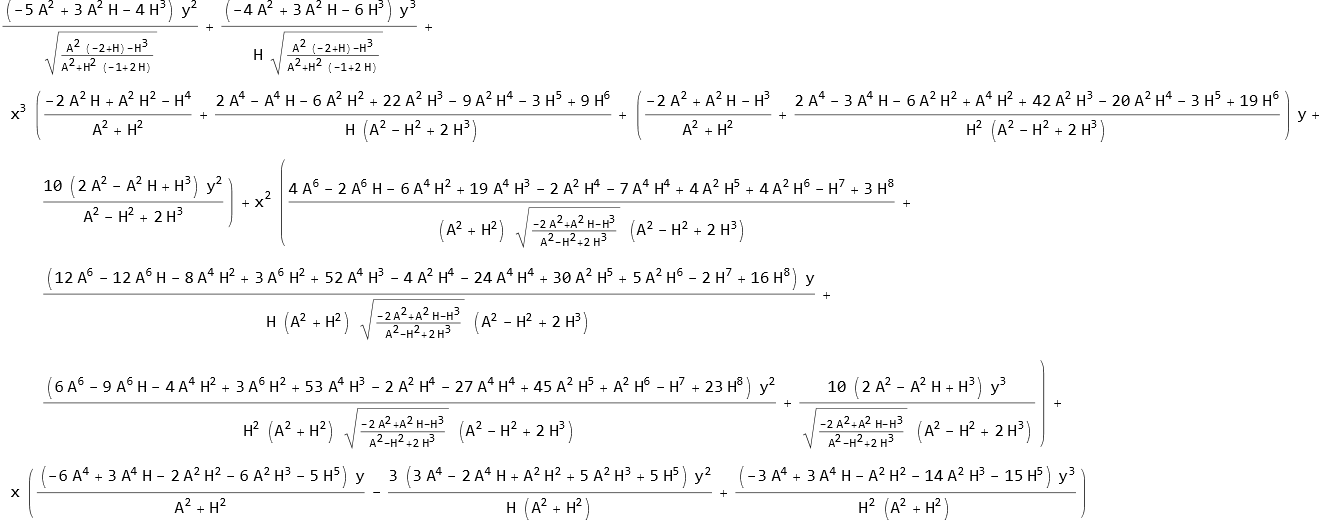
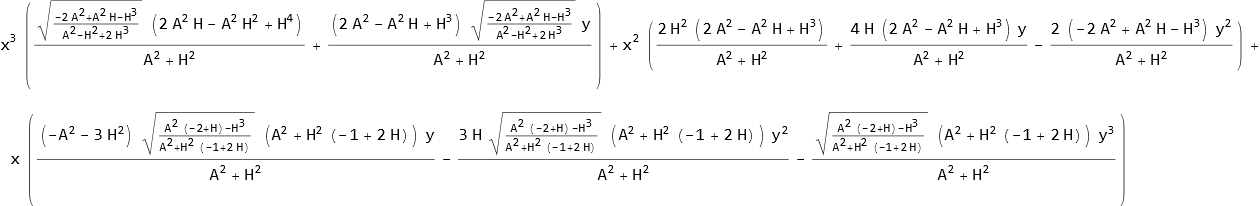

In [37]:
f1 = nonLinearNormal[[1]];
g1 = nonLinearNormal[[2]];
fn = Normal[Series[f1, {x, 0, 3}, {y, 0, 3}]]
gn = Normal[Series[g1, {x, 0, 3}, {y, 0, 3}]]

2             3
       4    2            2    4      5        A  (-2 + H) - H
2 (-2 A  + A  (3 - 7 H) H  + H  - 3 H ) Sqrt[------------------]
                                              2    2
                                             A  + H  (-1 + 2 H)
----------------------------------------------------------------
                             2    2
                            A  + H
    3      2
-8 H  + 2 A  (-5 + 3 H)
------------------------
       2             3
      A  (-2 + H) - H
Sqrt[------------------]
      2    2
     A  + H  (-1 + 2 H)
   4               5      2  2
3 A  (-2 + H) - 5 H  - 2 A  H  (1 + 3 H)
----------------------------------------
                 2    2
                A  + H
      2              3    4      2  2               4
6 (-(A  (-2 + H)) + H ) (A  + 3 A  H  (-1 + 3 H) + H  (-2 + 7 H))
-----------------------------------------------------------------
                    2    2    2    2
                H (A  + H ) (A  + H  (-1 + 2 H))
       2             2   2
   -3 A       2   2 A  (A  + H)
6 (----- - 5 H  + -------------)
     H                2    2
                     A  + H
   2     2              3
4 H  (-(A  (-2 + H)) + H )
--------------------------
          2    2
         A  + H
0
                     2             3
    2      2        A  (-2 + H) - H      2    2
  (A  + 3 H ) Sqrt[------------------] (A  + H  (-1 + 2 H))
                    2    2
                   A  + H  (-1 + 2 H)
-(---------------------------------------------------------)
                            2    2
                           A  + H
        2              3
8 H (-(A  (-2 + H)) + H )
-------------------------
          2    2
         A  + H
0
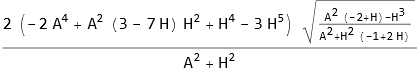
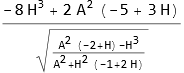
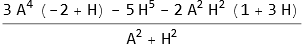
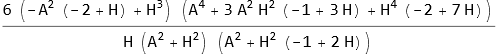
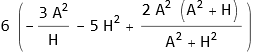
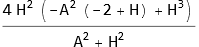
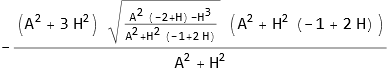
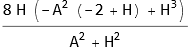

In [41]:
fxx  = FullSimplify[2  * SeriesCoefficient[fn, {x,0,2}, {y,0,0}]]
fyy  = FullSimplify[2  * SeriesCoefficient[fn, {x,0,0}, {y,0,2}]]
fxy  = FullSimplify[1  * SeriesCoefficient[fn, {x,0,1}, {y,0,1}]]
fxxx = FullSimplify[6  * SeriesCoefficient[fn, {x,0,3}, {y,0,0}]]
fxyy = FullSimplify[2  * SeriesCoefficient[fn, {x,0,1}, {y,0,2}]]

gxx  = FullSimplify[2  * SeriesCoefficient[gn, {x,0,2}, {y,0,0}]]
gyy  = FullSimplify[2  * SeriesCoefficient[gn, {x,0,0}, {y,0,2}]]
gxy  = FullSimplify[1  * SeriesCoefficient[gn, {x,0,1}, {y,0,1}]]
gxxy = FullSimplify[2  * SeriesCoefficient[gn, {x,0,2}, {y,0,1}]]
gyyy = FullSimplify[6  * SeriesCoefficient[gn, {x,0,0}, {y,0,3}]]

8                               10    2  7
(-3 A  (-2 + H) (-1 + H) - (-5 + H) H   + A  H  (-13 + (58 - 33 H) H) + 
 
       6  3                         4  4
>     A  H  (21 + H (-26 + 9 H)) + A  H  (-34 + H (119 + H (-90 + 17 H)))) / 
 
           2    2      2              3    2    2
>   (4 H (A  + H ) (-(A  (-2 + H)) + H ) (A  + H  (-1 + 2 H)))
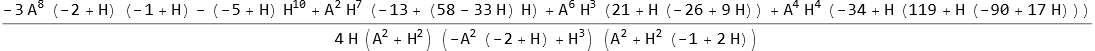

In [51]:
omega = Sqrt[detY[b]];

L1 = (1/16) * (
  (fxxx + fxyy + gxxy + gyyy) +
  (1/omega) * (fxy*(fxx + fyy) - gxy*(gxx + gyy) - fxx*gxx + fyy*gyy)
);

Assuming[
  {A > 0, 0 < H < 1/2, A^2 + H^2 > 0,
   A^2*(H-2) - H^3 < 0,
   A^2 + H^2*(2H-1) > 0},
  FullSimplify[L1]
]

In [54]:
l1[a_, h_] := L1 /. {A -> a, H -> h};

In [61]:
resultados = Table[
  Module[{h, maxa, a},
    h = RandomReal[{0.001, 0.499}];
    maxa = Sqrt[h^2 (1 - 2 h)];
    a = RandomReal[{0.001, maxa}];
    {a, h, l1[a, h]}
  ],
  {10}
]

{{0.155544, 0.370458, -0.385716}, {0.117889, 0.463632, -2.14732}, 
 
>   {0.116355, 0.157557, -0.000204861}, {0.0679821, 0.0878392, 0.037453}, 
 
>   {0.0114579, 0.0534916, -0.00146889}, {0.137558, 0.350735, -0.193726}, 
 
>   {0.10831, 0.404539, -0.151247}, {0.100725, 0.145024, -0.00444324}, 
 
>   {0.052893, 0.410442, -0.0303443}, {0.0495613, 0.472048, -0.0751757}}

In [107]:
CopyToClipboard[ToString[TeXForm[g]]]